## Initialize and Authenticate Earth Engine
To get started with Google Earth Engine (GEE), you need to initialize and authenticate the Earth Engine API. Follow these steps.


First, import the Earth Engine API by importing the ee module into your Python environment. This module allows you to interact with the Earth Engine platform.


In [1]:
# Import the API
import ee

Next, initialize the Earth Engine API.

In [2]:
# Trigger the authentication flow.
ee.Authenticate()

# Initialize the library.
ee.Initialize(project='ee-escuelavirtualgis') ## Change to your EE project

## Install and import libraries
Next, import the essential libraries needed to process and analyze the datasets.

In [3]:
# Import the necessary libraries
import geemap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Prepare predictor variables
This tutorial will use predictor variables such as Sentinel-2, the normalized difference vegetation index (NDVI), the soil-adjusted vegetation index (SAVI), the red edge spectral index (RESI)

In [ ]:
# Load the boundary
boundary = ee.FeatureCollection('projects/ee-escuelavirtualgis/assets/poligono')

In [17]:
#Punto de referencia
pt = ee.Geometry.Point(
  [-71.43162516650247, 1.9154175657060792]
);

# Cargar WDPA como FeatureCollection
wdpa = ee.FeatureCollection('WCMC/WDPA/current/polygons');

#Filtrar el área protegida que contiene el punto
boundary = wdpa.filterBounds(pt);

### Create Sentinel-2 composite
Next, load Sentinel-2 spectral reflectance data from the COPERNICUS 'S2_SR_HARMONIZED' image collection in Earth Engine. .


In [18]:
# Load Sentinel-2 spectral reflectance data.
s2 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')

# Create a function to mask clouds using the Sentinel-2 QA band.
def maskS2clouds(image):
    qa = image.select('QA60')
    # Bits 10 and 11 are clouds and cirrus, respectively.
    cloudBitMask = ee.Number(2).pow(10).int()
    cirrusBitMask = ee.Number(2).pow(11).int()
    # Both flags should be set to zero, indicating clear conditions.
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(
        qa.bitwiseAnd(cirrusBitMask).eq(0))
    # Return the masked and scaled data.
    return image.updateMask(mask).divide(10000)

# Create a single composite image for a given period.
start_date = '2019-01-01'
end_date = '2019-12-30'

# Filter clouds from Sentinel-2 for the given period.
composite = s2.filterDate(start_date, end_date) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
    .map(maskS2clouds) \
    .select(['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B11', 'B12'])  # Select bands for display

# Compute the median composite and clip to the boundary.
S2_composite = composite.median().clip(boundary)

# Initialize our map.
map1 = geemap.Map()
map1.centerObject(boundary, 12)

# Add the composite image to the map with specified display settings.
map1.addLayer(S2_composite, {'bands': ['B8', 'B5', 'B4'], 'min': 0, 'max': 0.3}, 'Sentinel-2 Composite')

# Display the map with layer control.
map1.addLayerControl()
map1

Map(center=[1.9378090753917285, -71.50590517413325], controls=(WidgetControl(options=['position', 'transparent…

### Compute spectral indices
Next, calculate NDVI, SAVI, and RESI from the Sentinel-2 composite. T

In [19]:
# Calculate NDVI
ndvi = S2_composite.normalizedDifference(['B8', 'B4']).rename('NDVI')

# Calculate SAVI.
L = 0.5  # Soil adjustment factor, typically between 0 and 1
savi = S2_composite.expression(
    '((NIR - Red) / (NIR + Red + L)) * (1 + L)', {
        'NIR': S2_composite.select('B8'),
        'Red': S2_composite.select('B4'),
        'L': L
    }).rename('SAVI')

# Calculate RESI
resi = S2_composite.expression(
    '((RE3 + RE2 - RE1) / (RE3 + RE2 + RE1))', {
        'RE1': S2_composite.select('B5'),
        'RE2': S2_composite.select('B6'),
        'RE3': S2_composite.select('B7')
    }).rename('RESI')

nbr = S2_composite \
  .normalizedDifference(['B8', 'B12']) \
  .rename('NBR')


# Initialize our map.
map2 = geemap.Map()
map2.centerObject(boundary, 12)

# Add the NDVI and RESI layers to the map.
map2.addLayer(ndvi, {'min': -1, 'max': 1, 'palette': ['blue', 'white', 'green']}, 'NDVI')
map2.addLayer(savi, {'min': -1, 'max': 1, 'palette': ['blue', 'white', 'green']}, 'SAVI')
map2.addLayer(resi, {'min': -1, 'max': 1, 'palette': ['blue', 'white', 'green']}, 'RESI')
map2.addLayer(nbr, {'min': -1, 'max': 1, 'palette': ['blue', 'white', 'green']}, 'NBR')


# Display the map with layer control.
map2.addLayerControl()
map2

Map(center=[1.9378090753917285, -71.50590517413325], controls=(WidgetControl(options=['position', 'transparent…

In [20]:

# Load Sentinel-1 GRD data (IW mode, dual-pol VV/VH).
s1 = ee.ImageCollection('COPERNICUS/S1_GRD')

# Create a function to mask invalid/edge pixels (análogo a la de nubes en S2).
def maskS1(image):
    # Mantén sólo píxeles válidos donde existan ambas polarizaciones (VV y VH).
    vvMask = image.select('VV').mask()
    vhMask = image.select('VH').mask()
    mask = vvMask.And(vhMask)
    return image.updateMask(mask)

# Create a single composite image for a given period.
start_date = '2019-01-01'
end_date   = '2019-12-30'

# Filter Sentinel-1 for the given period and required properties.
composite = (s1
    .filterDate(start_date, end_date)
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING')
            .Or(ee.Filter.eq('orbitProperties_pass', 'ASCENDING')))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
    .map(maskS1)
    .select(['VV', 'VH'])  # Select bands for display / variables
)

# Compute the median composite and clip to the boundary.
S1_composite = composite.median().clip(boundary)

# Initialize our map.
map1 = geemap.Map()
map1.centerObject(boundary, 12)

# Add the composite image to the map with specified display settings.
# (Para Sentinel-1 en escala lineal, estos rangos suelen funcionar bien.)
map1.addLayer(S1_composite, {'bands': ['VV', 'VH', 'VV'], 'min': -22, 'max': 0}, 'Sentinel-1 Composite (VV,VH)')

# Display the map with layer control.
map1.addLayerControl()
map1


Map(center=[1.9378090753916928, -71.50590517413336], controls=(WidgetControl(options=['position', 'transparent…

In [21]:
# Load Sentinel-1 GRD data (IW mode, dual-pol VV/VH).
s1 = ee.ImageCollection('COPERNICUS/S1_GRD')

# Create a function to mask invalid/edge pixels (analogous to cloud masking in S2).
def maskS1(image):
    # Keep only valid pixels where both VV and VH exist
    vvMask = image.select('VV').mask()
    vhMask = image.select('VH').mask()
    mask = vvMask.And(vhMask)
    return image.updateMask(mask)

# Create a single composite image for a given period.
start_date = '2019-01-01'
end_date   = '2019-12-30'

# Filter Sentinel-1 for the given period and required properties.
composite = (
    s1
    .filterDate(start_date, end_date)
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(
        ee.Filter.eq('orbitProperties_pass', 'DESCENDING')
        .Or(ee.Filter.eq('orbitProperties_pass', 'ASCENDING'))
    )
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
    .map(maskS1)
    .select(['VV', 'VH'])  # Select bands for display / variables
)

# Compute the median composite and clip to the boundary.
S1_composite = composite.median().clip(boundary)

# =======================
# SPECKLE FILTER
# =======================

# Base bands
vv = S1_composite.select('VV')
vh = S1_composite.select('VH')

# Ratio VV / VH
ratio = vv.divide(vh).rename('VV_VH_ratio')

# Apply speckle filter (focal mean, 30 m)
vvFiltered = vv.focal_mean(30, 'square', 'meters')
vhFiltered = vh.focal_mean(30, 'square', 'meters')
ratioFiltered = ratio.focal_mean(30, 'square', 'meters')

# merge filtered bands
S1_filtered = ee.Image.cat([
    vvFiltered.rename('VV_filtered'),
    vhFiltered.rename('VH_filtered'),
    ratioFiltered.rename('VV_VH_ratio_filtered')
]).clip(boundary)

# =======================
# MAP VISUALIZATION
# =======================

map1 = geemap.Map()
map1.centerObject(boundary, 12)

# Original composite
map1.addLayer(
    S1_composite,
    {'bands': ['VV', 'VH', 'VV'], 'min': -22, 'max': 0},
    'Sentinel-1 Composite (VV,VH)'
)

# Filtered layers
map1.addLayer(
    S1_filtered.select('VV_filtered'),
    {'min': -22, 'max': 0},
    'VV Speckle Filtered'
)

map1.addLayer(
    S1_filtered.select('VH_filtered'),
    {'min': -28, 'max': -5},
    'VH Speckle Filtered'
)

map1.addLayer(
    S1_filtered.select('VV_VH_ratio_filtered'),
    {'min': 0.3, 'max': 0.7},
    'VV/VH Ratio Speckle Filtered'
)

map1.addLayerControl()
map1


Map(center=[1.9378090753917285, -71.50590517413325], controls=(WidgetControl(options=['position', 'transparent…

### Merge all predictor variables


In [22]:
# Function to cast image bands to Float32
def cast_to_float32(image):
    return image.toFloat()

# Cast all images to Float32
S2_composite = cast_to_float32(S2_composite)
ndvi = cast_to_float32(ndvi)
savi = cast_to_float32(savi)
resi = cast_to_float32(resi)
nbr = cast_to_float32(nbr)
S1_filtered = cast_to_float32(S1_filtered)  # ✅ Agregado

# Define the merged collection
mergedCollection = (
    S2_composite
    .addBands(ndvi)
    .addBands(savi)
    .addBands(resi)
    .addBands(nbr)
    .addBands(S1_filtered)  # ✅ Agregado
)

# Clip the output image to the farm boundary
clippedmergedCollection = mergedCollection.clipToCollection(boundary)


## Prepare the response variable
### Filtering and preparing GEDI Level 4A data
Derive aboveground biomass density (AGBD) from the GEDI Level 4A (L4A) dataset. This dataset contains AGBD predictions in Mg/ha. More information about this dataset is available at: https://developers.google.com/earth-engine/datasets/catalog/LARSE_GEDI_GEDI04_A_002.


In [23]:
# Select a time-period
start_date = ee.Date.fromYMD(2019, 1, 1)
end_date = ee.Date.fromYMD(2019, 12, 30)

# Load the GEDI Level 4A dataset
gedi = ee.ImageCollection('LARSE/GEDI/GEDI04_A_002_MONTHLY')

# Function to select highest quality GEDI data
def quality_mask(image):
    return image.updateMask(image.select('l4_quality_flag').eq(1)) \
                .updateMask(image.select('degrade_flag').eq(0))

# Function to mask unreliable GEDI measurements with a relative standard error > 50%
def error_mask(image):
    relative_se = image.select('agbd_se').divide(image.select('agbd'))
    return image.updateMask(relative_se.lte(0.5))

# Function to mask GEDI measurements on slopes > 30%
def slope_mask(image):
    # Load the SRTM digital elevation model
    srtm = ee.Image('USGS/SRTMGL1_003')

    # Calculate slope
    slope = ee.Terrain.slope(srtm)

    return image.updateMask(slope.lt(30))

# Apply the filters
gedi_filtered = gedi.filter(ee.Filter.date(start_date, end_date)) \
                    .filter(ee.Filter.bounds(boundary))

gedi_projection = ee.Image(gedi_filtered.first()).select('agbd').projection()

gedi_processed = gedi_filtered.map(quality_mask).map(error_mask).map(slope_mask)

# Create a mosaic of the filtered images
gedi_mosaic = gedi_processed.mosaic().select('agbd').setDefaultProjection(gedi_projection).clip(boundary)

# Create the display parameters
gediVis = {
    'min': 1,
    'max': 300,
    'palette': 'red, green, blue',
}

### Sampling points and calculating key AGBD metrics

In [24]:
# Sample the training points (ta) from the dataset
points = gedi_mosaic.sample(
    region=boundary,
    scale=10,
    geometries=True
)

# Get the AGDB values from the 'agbd' property of the filtered points
agbd_values = points.aggregate_array('agbd').getInfo()

# Print the number of sampled points
print("Number of sampled points:", points.size().getInfo())

# Calculate summary statistics only if agbd_values is not empty
if agbd_values:
    mean_agbd = np.mean(agbd_values)
    median_agbd = np.median(agbd_values)
    std_agbd = np.std(agbd_values)
    min_agbd = np.min(agbd_values)
    max_agbd = np.max(agbd_values)

    # Print the summary statistics
    print("Mean AGBD:", mean_agbd)
    print("Median AGBD:", median_agbd)
    print("Standard Deviation AGBD:", std_agbd)
    print("Minimum AGBD:", min_agbd)
    print("Maximum AGBD:", max_agbd)
else:
    print("No AGBD values found after sampling. The 'agbd_values' list is empty.")
    # Assign NaN to stats to indicate no data, if these variables are used later
    mean_agbd = np.nan
    median_agbd = np.nan
    std_agbd = np.nan
    min_agbd = np.nan
    max_agbd = np.nan

# Print and display the training (ta) points derived from the GEDI L4B dataset
# Only attempt to print the first point if the collection is not empty
if points.size().getInfo() > 0:
    print("First sampled point info:", points.first().getInfo())
else:
    print("No points were sampled.")


Number of sampled points: 327093
Mean AGBD: 166.78325374768795
Median AGBD: 151.338242
Standard Deviation AGBD: 120.49466242822302
Minimum AGBD: 0.0
Maximum AGBD: 5009.88916
First sampled point info: {'type': 'Feature', 'geometry': {'geodesic': False, 'type': 'Point', 'coordinates': [-71.659276544069, 2.229543625324849]}, 'id': '0', 'properties': {'agbd': 135.648315}}


### Display GEDI Level 4A AGBD
Next, display GEDI AGBD sample points.

In [25]:
# Display the GEDI L4A mean above-ground biomass (AGB) points and the derived training points
# Initialize the map
map4 = geemap.Map()
map4.centerObject(boundary, 12)
map4.addLayer(gedi_mosaic, gediVis, 'GEDI L4A Mean AGBD points')
map4.addLayer(points, {'color': '808080'}, 'Mean AGBD training points')

# Display the map
display(map4)

The provided color (red, green, blue) is invalid. Using the default black color.
'#red, green, blue' is not in web format. Need 3 or 6 hex digit.


Map(center=[1.9378090753917285, -71.50590517413325], controls=(WidgetControl(options=['position', 'transparent…

Next, create density and box plots for the GEDI L4A datasets using the seaborn library for density plots and matplotlib for box plots.

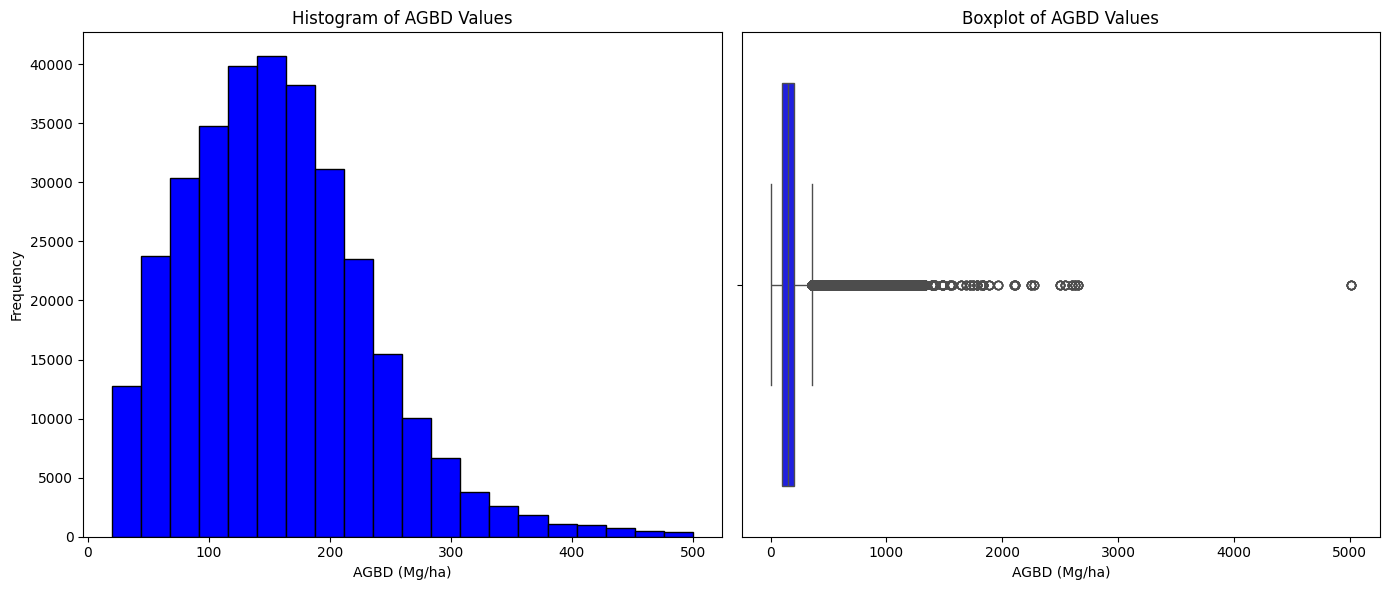

In [26]:
# Create a figure with 1 row and 2 columns
plt.figure(figsize=(14, 6))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(agbd_values, bins=20, range=[20, 500], color='blue', edgecolor='black')
plt.xlabel('AGBD (Mg/ha)')
plt.ylabel('Frequency')
plt.title('Histogram of AGBD Values')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=agbd_values, color='blue')
plt.xlabel('AGBD (Mg/ha)')
plt.title('Boxplot of AGBD Values')

# Display both plots
plt.tight_layout()
plt.show()

### Data cleaning

Next, we will filter the data points to retain aboveground biomass density (AGBD) values within 0 to 90 megagrams per hectare (Mg/ha).

In [27]:
# Filter the training points by range (0 Mg/ha to 100 Mg/ha)
filteredPoints = points.filter(
    ee.Filter.And(
        ee.Filter.gte('agbd', 10),
        ee.Filter.lte('agbd', 250)
    )
)

# Print and display the training (ta) points derived from the GEDI L4B dataset
print(filteredPoints.size().getInfo())
print(filteredPoints.first().getInfo())

# Display the GEDI L4A mean above-ground biomass (AGB) points and the derived training points
# Initialize the map
map5 = geemap.Map()
map5.centerObject(boundary, 12)
map5.addLayer(filteredPoints, {'color': '808080'}, 'Mean fitered AGBD training points')
# Display the map
display(map5)

284890
{'type': 'Feature', 'geometry': {'geodesic': False, 'type': 'Point', 'coordinates': [-71.659276544069, 2.229543625324849]}, 'id': '0', 'properties': {'agbd': 135.648315}}


Map(center=[1.9378090753916928, -71.50590517413336], controls=(WidgetControl(options=['position', 'transparent…

Mean AGBD: 139.3146494023017
Median AGBD: 140.421234
Standard Deviation AGBD: 56.450385002994366
Minimum AGBD: 10.567928314208984
Maximum AGBD: 249.997223
327093
{'type': 'Feature', 'geometry': {'geodesic': False, 'type': 'Point', 'coordinates': [-71.659276544069, 2.229543625324849]}, 'id': '0', 'properties': {'agbd': 135.648315}}


<Figure size 1400x600 with 0 Axes>

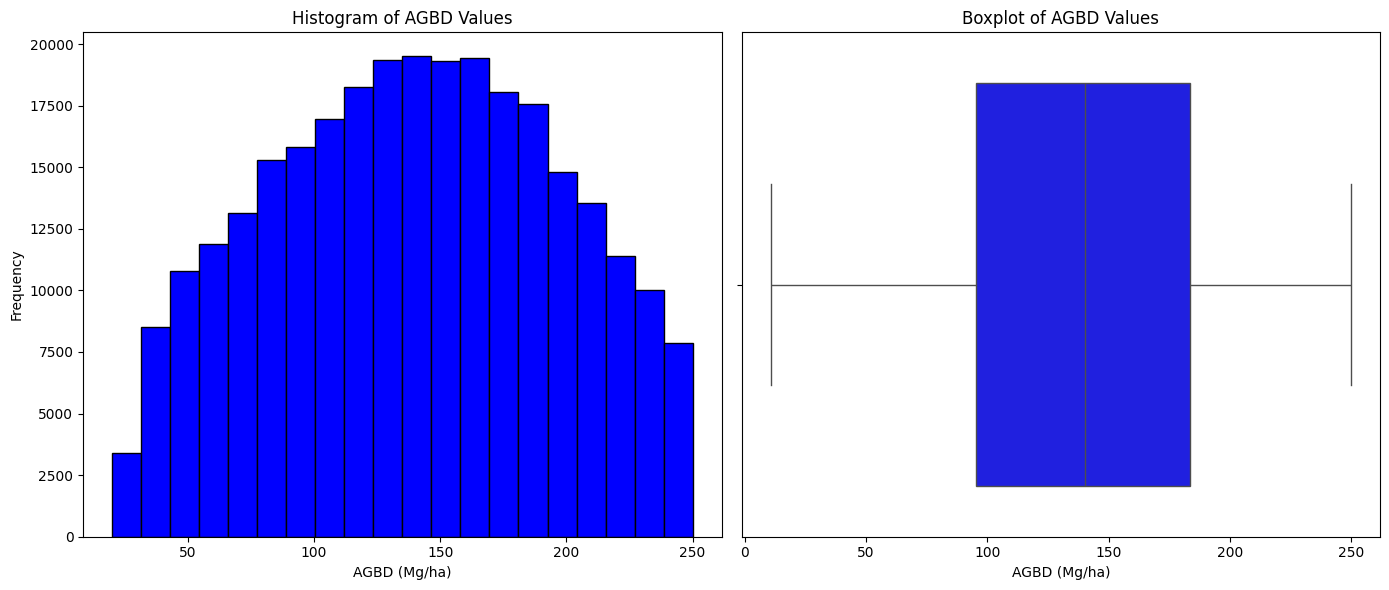

In [28]:
# Get the AGDB values from the 'agbd' property of the filtered points
agbd_values = filteredPoints.aggregate_array('agbd').getInfo()

# Calculate summary statistics
mean_agbd = np.mean(agbd_values)
median_agbd = np.median(agbd_values)
std_agbd = np.std(agbd_values)
min_agbd = np.min(agbd_values)
max_agbd = np.max(agbd_values)

# Print the summary statistics
print("Mean AGBD:", mean_agbd)
print("Median AGBD:", median_agbd)
print("Standard Deviation AGBD:", std_agbd)
print("Minimum AGBD:", min_agbd)
print("Maximum AGBD:", max_agbd)

# Print and display the training (ta) points derived from the GEDI L4B dataset
print(points.size().getInfo())
print(points.first().getInfo())

# Create a figure with 1 row and 2 columns
plt.figure(figsize=(14, 6))

# Create a figure with 1 row and 2 columns
plt.figure(figsize=(14, 6))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(agbd_values, bins=20, range=[20, 250], color='blue', edgecolor='black')
plt.xlabel('AGBD (Mg/ha)')
plt.ylabel('Frequency')
plt.title('Histogram of AGBD Values')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=agbd_values, color='blue')
plt.xlabel('AGBD (Mg/ha)')
plt.title('Boxplot of AGBD Values')

# Display both plots
plt.tight_layout()
plt.show()

## Sampling training data in Google Earth Engine
We will select specific bands from the 'clippedmergedCollection' and then sample the values (spectral reflectance values) at the locations of the 'trainingData' points.


In [ ]:
# Select specific bands or variables from the 'clippedmergedCollection'
predictor_vars = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B11', 'B12', 'NDVI', 'SAVI', 'RESI','NBR',
                  'VV_filtered', 'VH_filtered','VV_VH_ratio_filtered']  # ← Agregadas bandas de Sentinel-1

# Sample the values at the locations of the 'trainingData' points.
trainingData = clippedmergedCollection.select(predictor_vars).sampleRegions(**{
    'collection': filteredPoints,  # The 'trainingData' is the FeatureCollection containing training points.
    'properties': ['agbd'],        # The property 'agbd' is used as the label for the training points.
    'scale': 20                    # The scale (resolution) at which the sampling is performed (in meters).
})




## Export imagery and training data to Google Drive
Next, we will export the imagery and training data to your Google Drive since we want to use machine learning algorithms available in Scikit Learn.

In [ ]:
# Export the training data to Google Drive
task = ee.batch.Export.table.toDrive(**{
    'collection': trainingData,
    'description': 'TA_AGDD_GEDI_L4A_ejemplo',
    'folder': 'ejemplo',
    'fileFormat': 'CSV'
})

task.start()

print("Exporting the training data to Google Drive. This may take a while...")

Exporting the training data to Google Drive. This may take a while...


In [ ]:
# Export the training data to Google Drive
task = ee.batch.Export.image.toDrive(**{
    'image': clippedmergedCollection,
    'description': 'S2_predictors_ejemplo',
    'folder': 'mangrove',
    'fileNamePrefix': 'S2_predictors_ejemplo',
    'region': boundary.geometry().bounds().getInfo()['coordinates'],
    'scale': 20,
    'fileFormat': 'GeoTIFF'
})

task.start()

# Export the training data to Google Drive
task = ee.batch.Export.table.toDrive(**{
    'collection': trainingData,
    'description': 'TA_AGDD_GEDI_L4A_ejemplo',
    'folder': 'ejemplo',
    'fileFormat': 'CSV'
})

task.start()

print("Exporting the training data to Google Drive. This may take a while...")

NameError: name 'ee' is not defined

In [ ]:
# ----------------------------------------
# 1) Agregar columna aleatoria
# ----------------------------------------
trainingData_random = trainingData.randomColumn('rand')

# ----------------------------------------
# 2) Seleccionar aleatoriamente la mitad
#    (rand < 0.5 ≈ 50%)
# ----------------------------------------
trainingData_half = trainingData_random.filter(
    ee.Filter.lt('rand', 0.5)
)

# (Opcional pero MUY recomendado) quitar geometría
trainingData_half = trainingData_half.map(
    lambda f: f.setGeometry(None)
)

# ----------------------------------------
# 3) Exportar a Google Drive
# ----------------------------------------
task = ee.batch.Export.table.toDrive(**{
    'collection': trainingData_half,
    'description': 'TA_AGDD_GEDI_L4A_ejemplo_half_random',
    'folder': 'ejemplo',
    'fileFormat': 'CSV'
})

task.start()

print("Exporting RANDOM 50% of training data to Google Drive. This may take a while...")


Exporting RANDOM 50% of training data to Google Drive. This may take a while...
